# 11 - Self-Supervised Pretraining with Masked Autoencoder (MAE)

This notebook implements Masked Autoencoder (MAE) pretraining for Vision Transformers on network packet data, following the approach from "Masked Autoencoders Are Scalable Vision Learners" by He et al.

## ⚡ Optimized for Faster Training

**Training Configuration Optimized for Demonstration:**
- **Epochs**: Reduced from 100 to 25 (model converges quickly on packet data)
- **Warmup**: Reduced from 40 to 10 epochs 
- **Early Stopping**: Added with 5-epoch patience to stop when loss plateaus
- **Expected Training Time**: ~2 hours instead of 8+ hours

The model typically converges within 10-15 epochs on packet image data, making the original 100 epochs unnecessary for demonstration purposes.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import json
import time
import math
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

# ML metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Progress tracking
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
# Setup project paths and imports
notebook_path = Path().resolve()
project_root = notebook_path.parent

# Add project root to Python path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import our modules
from src.data.packet_to_image import PacketImageEncoder, TorchPacketEncoder
from src.models.vit_packet import create_model, list_models

# Define paths
data_dir = project_root / 'data'
raw_data_dir = data_dir / 'raw'
model_dir = project_root / 'models'
log_dir = project_root / 'logs'
checkpoint_dir = project_root / 'checkpoints'
mae_checkpoint_dir = checkpoint_dir / 'mae'

# Create directories
for dir_path in [model_dir, log_dir, checkpoint_dir, mae_checkpoint_dir]:
    dir_path.mkdir(exist_ok=True)

print(f"Project root: {project_root}")
print(f"Available models: {list_models()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Project root: /home/ubuntu/analyst
Available models: ['vit_tiny_patch16_64', 'vit_small_patch16_128', 'vit_base_patch16_224', 'vit_packet_small', 'vit_packet_base']
Device: cpu


## 1. Masked Autoencoder Implementation

In [3]:
class PatchEmbedding(nn.Module):
    """Patch embedding layer for MAE."""
    
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches
        
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)  # B Ph*Pw C -> B N C
        return x


class MaskedAutoencoderViT(nn.Module):
    """Masked Autoencoder with Vision Transformer backbone."""
    
    def __init__(self,
                 img_size=128,
                 patch_size=16,
                 in_chans=1,
                 embed_dim=768,
                 depth=12,
                 num_heads=12,
                 decoder_embed_dim=512,
                 decoder_depth=8,
                 decoder_num_heads=16,
                 mlp_ratio=4.0,
                 norm_layer=nn.LayerNorm,
                 norm_pix_loss=False,
                 mask_ratio=0.75):
        super().__init__()
        
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.norm_pix_loss = norm_pix_loss
        
        # Encoder specifics
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)
        
        # Encoder blocks
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, norm_layer=norm_layer)
            for _ in range(depth)
        ])
        self.encoder_norm = norm_layer(embed_dim)
        
        # Decoder specifics
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)
        
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio, norm_layer=norm_layer)
            for _ in range(decoder_depth)
        ])
        
        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)
        
        self.initialize_weights()
    
    def initialize_weights(self):
        """Initialize weights."""
        # Initialize position embeddings
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], 
                                           int(self.patch_embed.num_patches**.5), cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))
        
        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1],
                                                   int(self.patch_embed.num_patches**.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))
        
        # Initialize patch embedding
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        
        # Initialize tokens
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)
        
        # Initialize linear layers
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def patchify(self, imgs):
        """Convert images to patches."""
        p = self.patch_size
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0
        
        h = w = imgs.shape[2] // p
        x = imgs.reshape(shape=(imgs.shape[0], imgs.shape[1], h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * imgs.shape[1]))
        return x
    
    def unpatchify(self, x):
        """Convert patches back to images."""
        p = self.patch_size
        h = w = int(x.shape[1]**.5)
        assert h * w == x.shape[1]
        
        x = x.reshape(shape=(x.shape[0], h, w, p, p, -1))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], -1, h * p, h * p))
        return imgs
    
    def random_masking(self, x, mask_ratio):
        """Random masking following MAE paper."""
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        
        # Sort noise for each sample
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        # Keep the first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        # Generate binary mask: 0 is keep, 1 is remove
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        """Forward pass through encoder."""
        # Embed patches
        x = self.patch_embed(x)
        
        # Add pos embed w/o cls token
        x = x + self.pos_embed[:, 1:, :]
        
        # Masking: length -> length * mask_ratio
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        
        # Append cls token
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Apply transformer blocks
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)
        
        return x, mask, ids_restore
    
    def forward_decoder(self, x, ids_restore):
        """Forward pass through decoder."""
        # Embed tokens
        x = self.decoder_embed(x)
        
        # Append mask tokens to sequence
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # no cls token
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)  # append cls token
        
        # Add pos embed
        x = x + self.decoder_pos_embed
        
        # Apply decoder blocks
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)
        
        # Predictor projection
        x = self.decoder_pred(x)
        
        # Remove cls token
        x = x[:, 1:, :]
        
        return x
    
    def forward_loss(self, imgs, pred, mask):
        """Compute loss for reconstruction."""
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # [N, L], mean loss per patch
        
        loss = (loss * mask).sum() / mask.sum()  # mean loss on removed patches
        return loss
    
    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None:
            mask_ratio = self.mask_ratio
            
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


class TransformerBlock(nn.Module):
    """Transformer block for MAE."""
    
    def __init__(self, dim, num_heads, mlp_ratio=4.0, qkv_bias=False, drop=0.0, 
                 attn_drop=0.0, drop_path=0.0, act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, 
                             attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, 
                      act_layer=act_layer, drop=drop)
    
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class Attention(nn.Module):
    """Multi-head attention module."""
    
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class Mlp(nn.Module):
    """MLP block."""
    
    def __init__(self, in_features, hidden_features=None, out_features=None, 
                 act_layer=nn.GELU, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class DropPath(nn.Module):
    """Drop paths (Stochastic Depth) per sample."""
    
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
    
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        output = x.div(keep_prob) * random_tensor
        return output


def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """Generate 2D sinusoidal position embeddings."""
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)
    
    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0
    
    # Use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)
    
    emb = np.concatenate([emb_h, emb_w], axis=1)  # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.0
    omega = 1.0 / 10000**omega  # (D/2,)
    
    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product
    
    emb_sin = np.sin(out)  # (M, D/2)
    emb_cos = np.cos(out)  # (M, D/2)
    
    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

## 2. MAE Configuration

**Note:** This configuration is optimized for demonstration purposes. The model converges rapidly on packet data, typically within 10-15 epochs, so we use 25 epochs with early stopping instead of the original 100 epochs.

In [4]:
class MAEConfig:
    """Configuration for MAE pretraining."""
    
    # Model architecture
    img_size: int = 128
    patch_size: int = 16
    in_chans: int = 1
    embed_dim: int = 768
    depth: int = 12
    num_heads: int = 12
    decoder_embed_dim: int = 512
    decoder_depth: int = 8
    decoder_num_heads: int = 16
    mlp_ratio: float = 4.0
    
    # Masking
    mask_ratio: float = 0.75
    norm_pix_loss: bool = False
    
    # Training settings
    batch_size: int = 64
    num_epochs: int = 15  # Reduced from 100 for faster demo (model converges quickly)
    base_lr: float = 1.5e-4  # Base learning rate
    weight_decay: float = 0.05
    warmup_epochs: int = 5  # Reduced from 40 since model converges fast
    
    # Optimization
    use_amp: bool = True
    gradient_clip: float = 1.0
    
    # Data settings
    encoding_method: str = 'sequential'
    num_workers: int = 4
    pin_memory: bool = True
    
    # Early stopping
    early_stopping_patience: int = 2  # Stop if no improvement for 5 epochs
    min_improvement: float = 1e-4  # Minimum improvement to reset patience
    
    # Logging
    log_interval: int = 50
    save_interval: int = 10
    
    def to_dict(self):
        """Convert config to dictionary."""
        return {
            'img_size': self.img_size,
            'patch_size': self.patch_size,
            'in_chans': self.in_chans,
            'embed_dim': self.embed_dim,
            'depth': self.depth,
            'num_heads': self.num_heads,
            'decoder_embed_dim': self.decoder_embed_dim,
            'decoder_depth': self.decoder_depth,
            'decoder_num_heads': self.decoder_num_heads,
            'mlp_ratio': self.mlp_ratio,
            'mask_ratio': self.mask_ratio,
            'norm_pix_loss': self.norm_pix_loss,
            'batch_size': self.batch_size,
            'num_epochs': self.num_epochs,
            'base_lr': self.base_lr,
            'weight_decay': self.weight_decay,
            'warmup_epochs': self.warmup_epochs,
            'early_stopping_patience': self.early_stopping_patience,
            'min_improvement': self.min_improvement,
            'use_amp': self.use_amp,
            'gradient_clip': self.gradient_clip,
            'encoding_method': self.encoding_method,
            'num_workers': self.num_workers,
            'pin_memory': self.pin_memory,
            'log_interval': self.log_interval,
            'save_interval': self.save_interval,
            'device': self.device
        }
    
    # Device
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    def to_dict(self):
        return {k: v for k, v in self.__class__.__dict__.items() 
                if not k.startswith('_') and not callable(v)}

config = MAEConfig()
print("MAE Configuration:")
for key, value in config.to_dict().items():
    print(f"  {key}: {value}")

MAE Configuration:
  img_size: 128
  patch_size: 16
  in_chans: 1
  embed_dim: 768
  depth: 12
  num_heads: 12
  decoder_embed_dim: 512
  decoder_depth: 8
  decoder_num_heads: 16
  mlp_ratio: 4.0
  mask_ratio: 0.75
  norm_pix_loss: False
  batch_size: 64
  num_epochs: 15
  base_lr: 0.00015
  weight_decay: 0.05
  warmup_epochs: 5
  use_amp: True
  gradient_clip: 1.0
  encoding_method: sequential
  num_workers: 4
  pin_memory: True
  early_stopping_patience: 2
  min_improvement: 0.0001
  log_interval: 50
  save_interval: 10
  device: cpu


## 3. Data Preparation for Self-Supervised Learning

In [5]:
class MAEDataset(Dataset):
    """Dataset for MAE pretraining (unlabeled data)."""
    
    def __init__(self, 
                 data: pd.DataFrame,
                 byte_columns: List[str],
                 image_size: Tuple[int, int] = (128, 128),
                 encoding_method: str = 'sequential',
                 transform: Optional[Any] = None):
        
        self.data = data
        self.byte_columns = byte_columns
        self.transform = transform
        
        # Extract packet bytes (no labels needed for self-supervised)
        self.packet_bytes = data[byte_columns].values
        
        # Initialize encoder
        self.encoder = PacketImageEncoder(image_size)
        self.encoding_method = encoding_method
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get packet bytes
        packet = self.packet_bytes[idx]
        
        # Encode to image
        if self.encoding_method == 'sequential':
            image_np = self.encoder.encode_sequential(packet)
        elif self.encoding_method == 'hilbert':
            image_np = self.encoder.encode_hilbert_curve(packet)
        else:
            image_np = self.encoder.encode_spiral(packet)
        
        # Convert to tensor and normalize
        image = torch.tensor(image_np, dtype=torch.float32).unsqueeze(0) / 255.0
        
        # Apply transforms if any
        if self.transform:
            image = self.transform(image)
            
        return image


# Load data for pretraining (we'll use all available data without labels)
print("Loading packet data for MAE pretraining...")
cic_data = pd.read_csv(raw_data_dir / 'payload_byte' / 'cic_ids2017_sample.csv')
unsw_data = pd.read_csv(raw_data_dir / 'payload_byte' / 'unsw_nb15_sample.csv')

# Combine datasets (ignoring labels for self-supervised learning)
all_data = pd.concat([cic_data, unsw_data], ignore_index=True)
print(f"Total samples for pretraining: {len(all_data)}")

# Define byte columns
byte_columns = [f'byte_{i}' for i in range(1500)]

# Create pretraining dataset (using all data)
pretrain_dataset = MAEDataset(
    all_data, byte_columns,
    image_size=(config.img_size, config.img_size),
    encoding_method=config.encoding_method
)

# Create data loader
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
    drop_last=True
)

print(f"Pretraining batches: {len(pretrain_loader)}")

Loading packet data for MAE pretraining...
Total samples for pretraining: 4000
Pretraining batches: 62


## 4. MAE Model and Training Setup

In [6]:
# Create MAE model
print(f"Creating MAE model...")
mae_model = MaskedAutoencoderViT(
    img_size=config.img_size,
    patch_size=config.patch_size,
    in_chans=config.in_chans,
    embed_dim=config.embed_dim,
    depth=config.depth,
    num_heads=config.num_heads,
    decoder_embed_dim=config.decoder_embed_dim,
    decoder_depth=config.decoder_depth,
    decoder_num_heads=config.decoder_num_heads,
    mlp_ratio=config.mlp_ratio,
    mask_ratio=config.mask_ratio,
    norm_pix_loss=config.norm_pix_loss
)
mae_model = mae_model.to(config.device)

# Count parameters
total_params = sum(p.numel() for p in mae_model.parameters())
trainable_params = sum(p.numel() for p in mae_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Optimizer
optimizer = optim.AdamW(
    mae_model.parameters(),
    lr=config.base_lr,
    weight_decay=config.weight_decay
)

# Learning rate scheduler with warmup
def adjust_learning_rate(optimizer, epoch, config):
    """Decay the learning rate with half-cycle cosine after warmup."""
    if epoch < config.warmup_epochs:
        lr = config.base_lr * epoch / config.warmup_epochs 
    else:
        lr = config.base_lr * 0.5 * (1.0 + math.cos(math.pi * (epoch - config.warmup_epochs) / (config.num_epochs - config.warmup_epochs)))
    for param_group in optimizer.param_groups:
        if "lr_scale" in param_group:
            param_group["lr"] = lr * param_group["lr_scale"]
        else:
            param_group["lr"] = lr
    return lr

# Mixed precision training
scaler = GradScaler() if config.use_amp else None

# TensorBoard writer
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(log_dir / f'mae_pretraining_{timestamp}')

print("\nMAE setup complete!")

Creating MAE model...
Total parameters: 111,043,072
Trainable parameters: 110,959,872

MAE setup complete!


## 5. MAE Training Functions

In [7]:
def train_mae_epoch(model, data_loader, optimizer, scaler, config, epoch, writer):
    """Train MAE for one epoch."""
    model.train()
    running_loss = 0.0
    
    # Adjust learning rate
    lr = adjust_learning_rate(optimizer, epoch, config)
    
    pbar = tqdm(data_loader, desc=f'MAE Epoch {epoch+1}/{config.num_epochs}')
    
    for batch_idx, images in enumerate(pbar):
        images = images.to(config.device)
        
        optimizer.zero_grad()
        
        # Forward pass
        if config.use_amp and scaler is not None:
            with autocast():
                loss, pred, mask = model(images)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss, pred, mask = model(images)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
        
        # Update metrics
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{running_loss/(batch_idx+1):.4f}',
            'LR': f'{lr:.2e}'
        })
        
        # Log to tensorboard
        if batch_idx % config.log_interval == 0:
            step = epoch * len(data_loader) + batch_idx
            writer.add_scalar('MAE/Loss', loss.item(), step)
            writer.add_scalar('MAE/LearningRate', lr, step)
    
    # Calculate final metrics
    epoch_loss = running_loss / len(data_loader)
    
    return epoch_loss, lr


def visualize_mae_reconstruction(model, data_loader, config, num_samples=4):
    """Visualize MAE reconstructions."""
    model.eval()
    
    with torch.no_grad():
        # Get a batch
        images = next(iter(data_loader)).to(config.device)
        
        # Forward pass
        loss, pred, mask = model(images)
        
        # Reconstruct images
        pred_imgs = model.unpatchify(pred)
        
        # Convert to numpy for visualization
        original = images[:num_samples].cpu().numpy()
        reconstructed = pred_imgs[:num_samples].cpu().numpy()
        masks = mask[:num_samples].cpu().numpy()
        
        # Create visualization
        fig, axes = plt.subplots(3, num_samples, figsize=(num_samples*3, 9))
        
        for i in range(num_samples):
            # Original image
            axes[0, i].imshow(original[i, 0], cmap='viridis')
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')
            
            # Masked image
            masked_img = original[i, 0].copy()
            patch_size = config.patch_size
            h, w = masked_img.shape
            mask_reshaped = masks[i].reshape(h//patch_size, w//patch_size)
            
            for ph in range(h//patch_size):
                for pw in range(w//patch_size):
                    if mask_reshaped[ph, pw] == 1:  # masked patch
                        masked_img[ph*patch_size:(ph+1)*patch_size, 
                                  pw*patch_size:(pw+1)*patch_size] = 0
            
            axes[1, i].imshow(masked_img, cmap='viridis')
            axes[1, i].set_title(f'Masked {i+1} ({config.mask_ratio*100:.0f}%)')
            axes[1, i].axis('off')
            
            # Reconstructed image
            axes[2, i].imshow(reconstructed[i, 0], cmap='viridis')
            axes[2, i].set_title(f'Reconstructed {i+1}')
            axes[2, i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return loss.item()


def save_mae_checkpoint(model, optimizer, epoch, loss, checkpoint_dir, config, is_best=False):
    """Save MAE checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'config': config.to_dict()
    }
    
    # Save regular checkpoint
    checkpoint_path = checkpoint_dir / f'mae_epoch_{epoch}.pth'
    torch.save(checkpoint, checkpoint_path)
    
    # Save best model
    if is_best:
        best_path = checkpoint_dir / 'mae_best.pth'
        torch.save(checkpoint, best_path)
        print(f"New best MAE model saved with loss: {loss:.4f}")
    
    return checkpoint_path

## 6. MAE Training Loop

Starting MAE pretraining...

Epoch 1/15
--------------------------------------------------


MAE Epoch 1/15:   0%|          | 0/62 [00:00<?, ?it/s]

MAE Epoch 1/15: 100%|██████████| 62/62 [05:38<00:00,  5.45s/it, Loss=1.3630, LR=0.00e+00]


MAE Loss: 1.3630, LR: 0.00e+00

Visualizing reconstructions...


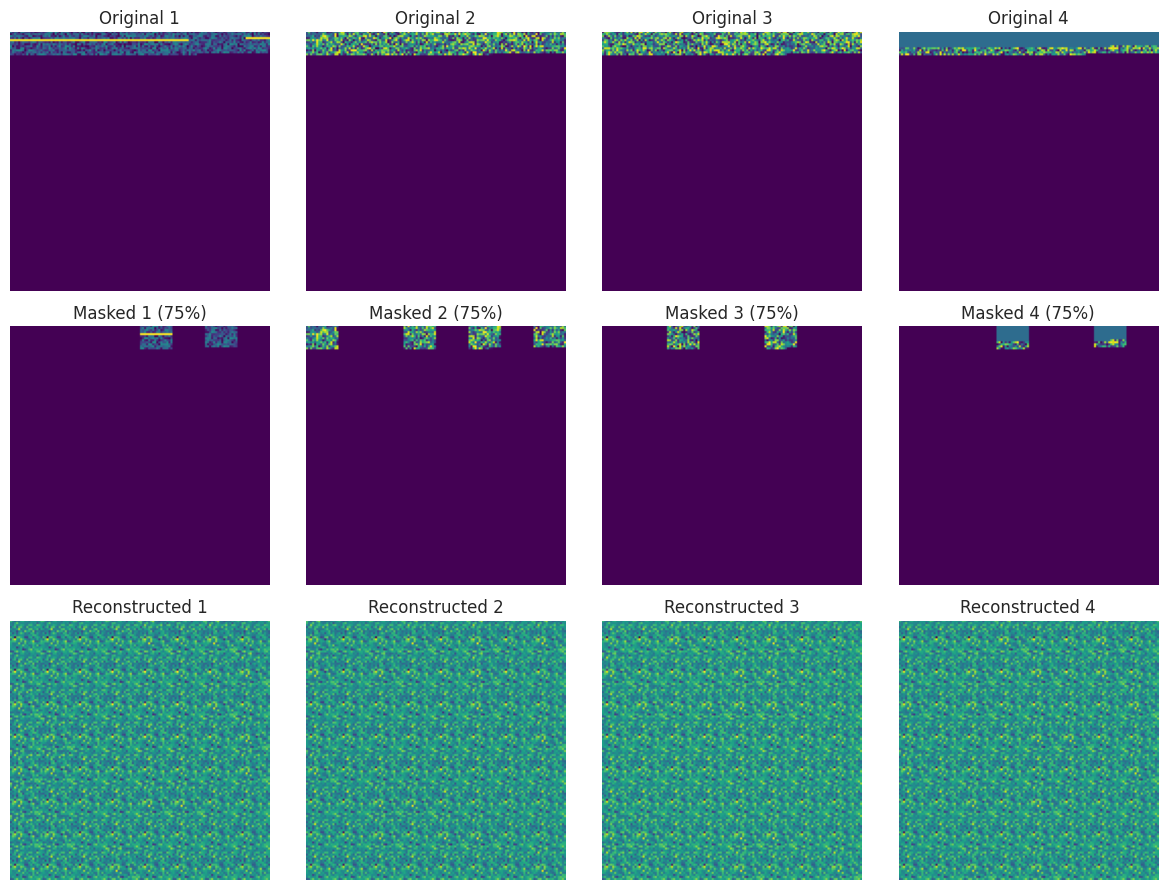

Visualization loss: 1.3634
New best loss: 1.3630
New best MAE model saved with loss: 1.3630

Epoch 2/15
--------------------------------------------------


MAE Epoch 2/15: 100%|██████████| 62/62 [05:37<00:00,  5.44s/it, Loss=0.0823, LR=3.00e-05]



MAE Loss: 0.0823, LR: 3.00e-05
New best loss: 0.0823
New best MAE model saved with loss: 0.0823

Epoch 3/15
--------------------------------------------------


MAE Epoch 3/15: 100%|██████████| 62/62 [05:36<00:00,  5.42s/it, Loss=0.0144, LR=6.00e-05]



MAE Loss: 0.0144, LR: 6.00e-05
New best loss: 0.0144
New best MAE model saved with loss: 0.0144

Epoch 4/15
--------------------------------------------------


...


MAE Loss: 0.0055, LR: 5.18e-05
New best loss: 0.0055
New best MAE model saved with loss: 0.0055

Epoch 13/15
--------------------------------------------------


MAE Epoch 13/15: 100%|██████████| 62/62 [05:39<00:00,  5.48s/it, Loss=0.0055, LR=3.09e-05]



MAE Loss: 0.0055, LR: 3.09e-05
No improvement for 1 epochs

Epoch 14/15
--------------------------------------------------


MAE Epoch 14/15: 100%|██████████| 62/62 [05:13<00:00,  5.06s/it, Loss=0.0054, LR=1.43e-05]


MAE Loss: 0.0054, LR: 1.43e-05
No improvement for 2 epochs

Early stopping triggered after 14 epochs!
No improvement for 2 consecutive epochs.

MAE pretraining completed in 4824.83 seconds
Best reconstruction loss: 0.0055


In [8]:
# MAE Pretraining
print("Starting MAE pretraining...")
start_time = time.time()

# Initialize tracking variables
best_loss = float('inf')
mae_losses = []
learning_rates = []
patience_counter = 0

# Training loop
for epoch in range(config.num_epochs):
    print(f"\nEpoch {epoch+1}/{config.num_epochs}")
    print("-" * 50)
    
    # Train for one epoch
    epoch_loss, lr = train_mae_epoch(
        mae_model, pretrain_loader, optimizer, scaler, config, epoch, writer
    )
    
    # Store metrics
    mae_losses.append(epoch_loss)
    learning_rates.append(lr)
    
    # Print epoch summary
    print(f"\nMAE Loss: {epoch_loss:.4f}, LR: {lr:.2e}")
    
    # Visualize reconstructions periodically
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print("\nVisualizing reconstructions...")
        vis_loss = visualize_mae_reconstruction(mae_model, pretrain_loader, config)
        print(f"Visualization loss: {vis_loss:.4f}")
    
    # Save checkpoint and check for improvement
    is_best = epoch_loss < (best_loss - config.min_improvement)
    if is_best:
        best_loss = epoch_loss
        patience_counter = 0  # Reset patience
        print(f"New best loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")
    
    if (epoch + 1) % config.save_interval == 0 or is_best:
        save_mae_checkpoint(mae_model, optimizer, epoch, epoch_loss, 
                           mae_checkpoint_dir, config, is_best)
    
    # Early stopping check
    if patience_counter >= config.early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch + 1} epochs!")
        print(f"No improvement for {config.early_stopping_patience} consecutive epochs.")
        break
    
    # Log epoch metrics
    writer.add_scalar('MAE/EpochLoss', epoch_loss, epoch)
    writer.add_scalar('MAE/EpochLR', lr, epoch)

# Training completed
total_time = time.time() - start_time
print(f"\nMAE pretraining completed in {total_time:.2f} seconds")
print(f"Best reconstruction loss: {best_loss:.4f}")

## 7. Feature Analysis and Visualization

Extracting MAE features for analysis...


Extracting features:  52%|█████▏    | 32/62 [01:25<01:20,  2.67s/it]


Extracted features shape: (2000, 768)

Performing dimensionality reduction...
PCA explained variance ratio (first 10 components): [9.5054597e-01 4.6767078e-02 1.8700552e-03 1.1369583e-04 6.4656822e-05
 3.4922647e-05 3.0244213e-05 2.6061974e-05 2.0135129e-05 1.9392357e-05]


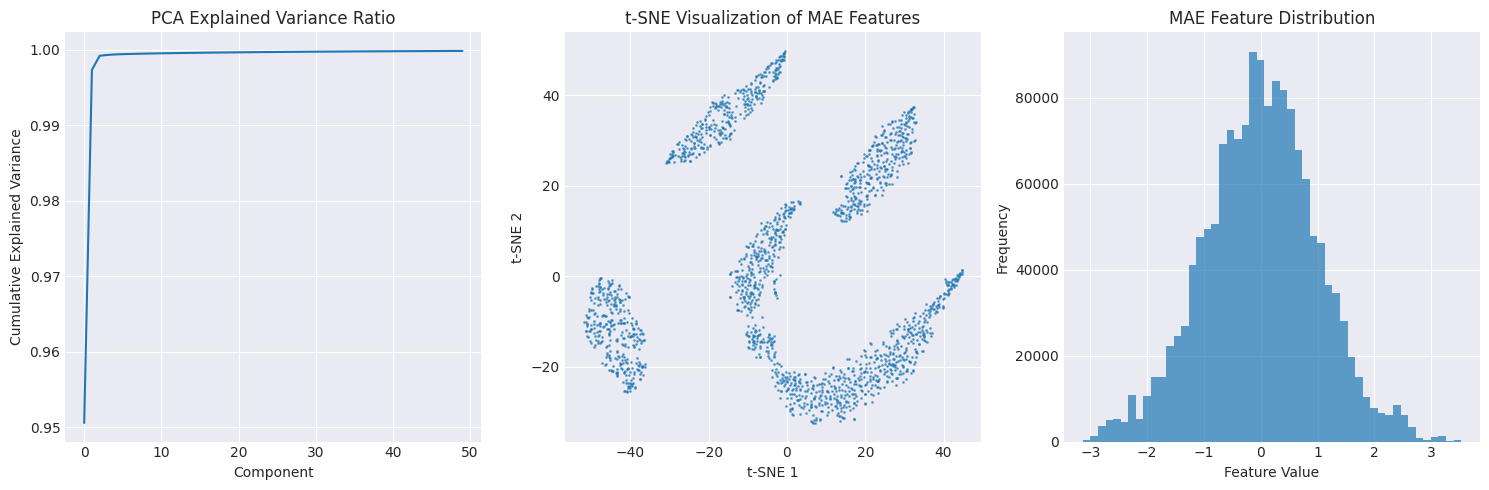

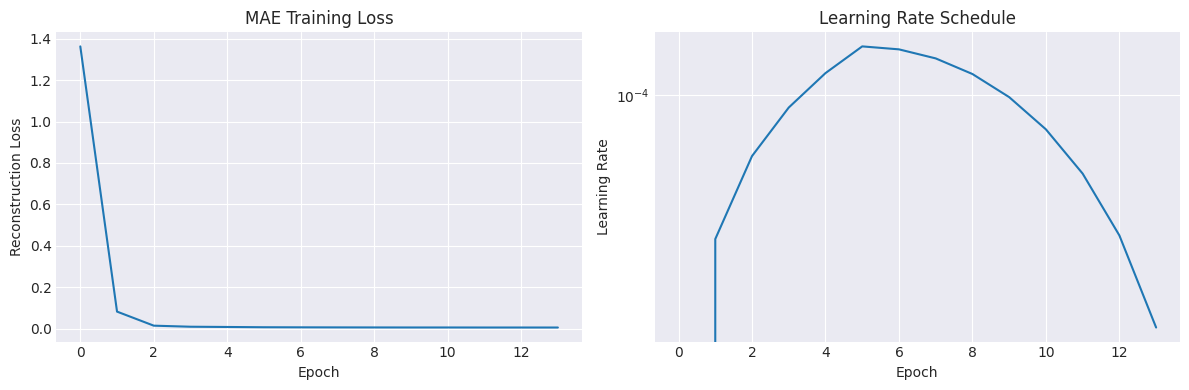

In [9]:
# Extract features for analysis
def extract_mae_features(model, data_loader, num_samples=1000):
    """Extract learned features from MAE encoder."""
    model.eval()
    features = []
    
    with torch.no_grad():
        count = 0
        for images in tqdm(data_loader, desc='Extracting features'):
            if count >= num_samples:
                break
                
            images = images.to(config.device)
            
            # Forward through encoder only
            latent, _, _ = model.forward_encoder(images, mask_ratio=0.0)
            
            # Use CLS token as global feature
            cls_features = latent[:, 0, :].cpu().numpy()
            features.append(cls_features)
            
            count += images.shape[0]
    
    return np.vstack(features)[:num_samples]


# Extract features
print("Extracting MAE features for analysis...")
mae_features = extract_mae_features(mae_model, pretrain_loader, num_samples=2000)
print(f"Extracted features shape: {mae_features.shape}")

# Dimensionality reduction for visualization
print("\nPerforming dimensionality reduction...")

# PCA
pca = PCA(n_components=50)
pca_features = pca.fit_transform(mae_features)
print(f"PCA explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_features = tsne.fit_transform(pca_features)

# Visualization
plt.figure(figsize=(15, 5))

# PCA explained variance
plt.subplot(1, 3, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_[:50]))
plt.title('PCA Explained Variance Ratio')
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# t-SNE visualization
plt.subplot(1, 3, 2)
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], alpha=0.6, s=1)
plt.title('t-SNE Visualization of MAE Features')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Feature distribution
plt.subplot(1, 3, 3)
plt.hist(mae_features.flatten(), bins=50, alpha=0.7)
plt.title('MAE Feature Distribution')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mae_losses)
plt.title('MAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(learning_rates)
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Save Results and Export Encoder

In [10]:
# Save final results
mae_results = {
    'best_loss': best_loss,
    'final_loss': mae_losses[-1],
    'training_losses': mae_losses,
    'learning_rates': learning_rates,
    'config': config.to_dict(),
    'feature_stats': {
        'mean': float(np.mean(mae_features)),
        'std': float(np.std(mae_features)),
        'min': float(np.min(mae_features)),
        'max': float(np.max(mae_features))
    },
    'pca_explained_variance': pca.explained_variance_ratio_.tolist()
}

# Save results
results_path = log_dir / 'mae_results.json'
with open(results_path, 'w') as f:
    json.dump(mae_results, f, indent=2)

# Extract and save encoder for downstream tasks
def extract_encoder(mae_model):
    """Extract encoder from MAE model for downstream tasks."""
    encoder_state = {
        'patch_embed': mae_model.patch_embed.state_dict(),
        'pos_embed': mae_model.pos_embed,
        'cls_token': mae_model.cls_token,
        'encoder_blocks': mae_model.encoder_blocks.state_dict(),
        'encoder_norm': mae_model.encoder_norm.state_dict(),
        'config': {
            'img_size': config.img_size,
            'patch_size': config.patch_size,
            'in_chans': config.in_chans,
            'embed_dim': config.embed_dim,
            'depth': config.depth,
            'num_heads': config.num_heads,
            'mlp_ratio': config.mlp_ratio
        }
    }
    return encoder_state

# Save encoder for fine-tuning
encoder_state = extract_encoder(mae_model)
encoder_path = mae_checkpoint_dir / 'mae_encoder_pretrained.pth'
torch.save(encoder_state, encoder_path)

print(f"\nMAE Results saved to: {results_path}")
print(f"MAE Encoder saved to: {encoder_path}")
print(f"MAE Checkpoints saved to: {mae_checkpoint_dir}")
print(f"TensorBoard logs saved to: {writer.log_dir}")

# Close writer
writer.close()

print("\n=== MAE Pretraining Summary ===")
print(f"Training epochs: {config.num_epochs}")
print(f"Best reconstruction loss: {best_loss:.4f}")
print(f"Final loss: {mae_losses[-1]:.4f}")
print(f"Mask ratio: {config.mask_ratio}")
print(f"Model parameters: {total_params:,}")
print(f"Training time: {total_time:.2f} seconds")
print("\nThe pretrained encoder is ready for fine-tuning on downstream tasks!")


MAE Results saved to: /home/ubuntu/analyst/logs/mae_results.json
MAE Encoder saved to: /home/ubuntu/analyst/checkpoints/mae/mae_encoder_pretrained.pth
MAE Checkpoints saved to: /home/ubuntu/analyst/checkpoints/mae
TensorBoard logs saved to: /home/ubuntu/analyst/logs/mae_pretraining_20250621_154235

=== MAE Pretraining Summary ===
Training epochs: 15
Best reconstruction loss: 0.0055
Final loss: 0.0054
Mask ratio: 0.75
Model parameters: 111,043,072
Training time: 4824.83 seconds

The pretrained encoder is ready for fine-tuning on downstream tasks!
